# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
#load cleaned dataset 

cleaned_df = pd.read_csv('data/cleanedAviationData.csv')
cleaned_df.head(10)

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Country,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,...,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers,Destroyed
0,20001214X38957,Accident,ATL84LA120,3/14/1984,United States,Non-Fatal,Substantial,Airplane,N7994R,Beech,...,0,0,0,1,VMC,Landing,Probable Cause,24-09-2018,1,0
1,20001214X40033,Accident,MIA84LA182,6/11/1984,United States,Non-Fatal,Substantial,Airplane,N29994,Piper,...,0,0,0,4,VMC,Approach,Probable Cause,13-09-2011,4,0
2,20001214X40407,Accident,MKC84FA197,7/3/1984,United States,Fatal(1),Destroyed,Airplane,N4025,Piper,...,1,0,0,0,VMC,Maneuvering,Probable Cause,15-12-2009,1,1
3,20001214X41647,Accident,MKC85LA019,11/9/1984,United States,Non-Fatal,Substantial,Airplane,N13030,Cessna,...,0,0,0,1,VMC,Approach,Probable Cause,2/5/2011,1,0
4,20001214X41706,Accident,ATL85FA072,12/30/1984,United States,Fatal(1),Destroyed,Airplane,N4963D,Cessna,...,1,0,0,0,VMC,Maneuvering,Probable Cause,17-10-2016,1,1
5,20001214X35509,Accident,DEN85LA064,1/14/1985,United States,Non-Fatal,Destroyed,Airplane,N759WB,Cessna,...,0,1,1,0,VMC,Maneuvering,Probable Cause,12/1/2016,2,1
6,20001214X36510,Accident,LAX85LA257,5/13/1985,United States,Non-Fatal,Destroyed,Airplane,N4661V,Cessna,...,0,1,0,0,VMC,Approach,Probable Cause,3/8/2011,1,1
7,20001214X36887,Accident,NYC85FA145B,6/11/1985,United States,Fatal(1),Destroyed,Airplane,N4956B,Cessna,...,1,1,4,0,VMC,Takeoff,Probable Cause,8/4/2013,6,1
8,20001214X37356,Incident,ATL85IA251,8/16/1985,United States,Incident,Substantial,Airplane,N2624D,Cessna,...,0,0,0,4,VMC,Landing,Probable Cause,26-07-2011,4,0
9,20001214X37718,Accident,ATL85MA286,9/29/1985,United States,Fatal(17),Destroyed,Airplane,N551CC,Cessna,...,17,0,0,0,VMC,Takeoff,Probable Cause,17-10-2016,17,1


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
#create new column 'Plane.size' based on number of total passengers in a plane(<20:'small',>20:'large')
cleaned_df['Plane.size'] = cleaned_df['Total_Passengers'].apply(lambda x: 'Small' if x <= 20 else 'Large')
#check for the number of large planes
(cleaned_df['Plane.size'] == 'Large').sum()
cleaned_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17836 entries, 0 to 17835
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Event.Id                17836 non-null  object
 1   Investigation.Type      17836 non-null  object
 2   Accident.Number         17836 non-null  object
 3   Event.Date              17836 non-null  object
 4   Country                 17836 non-null  object
 5   Injury.Severity         17836 non-null  object
 6   Aircraft.damage         17836 non-null  object
 7   Aircraft.Category       17836 non-null  object
 8   Registration.Number     17836 non-null  object
 9   Make                    17836 non-null  object
 10  Model                   17836 non-null  object
 11  Amateur.Built           17836 non-null  object
 12  Number.of.Engines       17836 non-null  int64 
 13  Engine.Type             17836 non-null  object
 14  FAR.Description         17836 non-null  object
 15  Pu

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

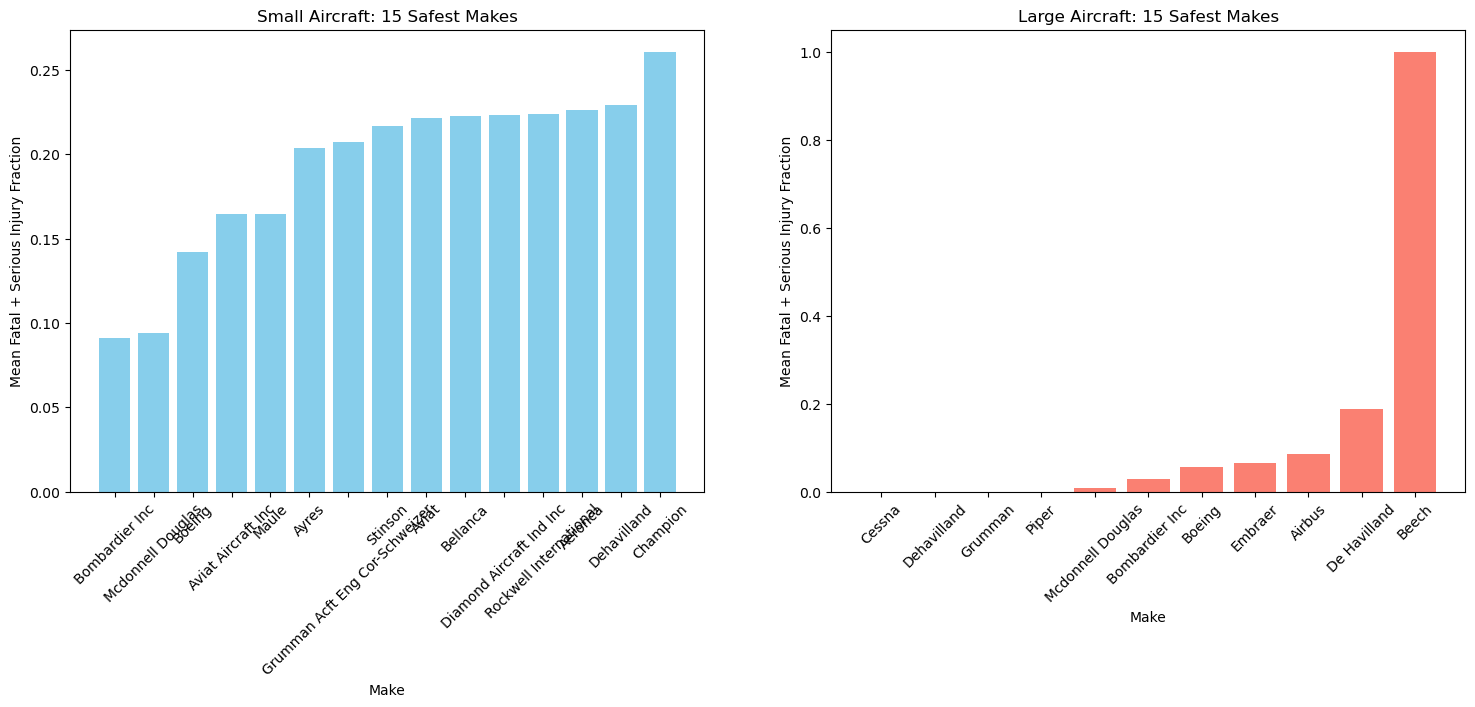

In [4]:
#find which 15 plane makes among SMALL AND LARGE planes have the lowest fatal/serious injury rate 

cleaned_df['Injury_Fraction']=(
    cleaned_df['Total.Fatal.Injuries'].fillna(0)+
    cleaned_df['Total.Serious.Injuries'].fillna(0))/  cleaned_df['Total_Passengers'].replace(0, np.nan)

grouped = (
    cleaned_df
    .groupby(['Make', 'Plane.size'])['Injury_Fraction']#group_by_manufacturer  + size
    .mean() #compute the mean severity
    .reset_index() #convert back to dataframe
)

small = grouped[grouped['Plane.size'] == 'Small'].sort_values('Injury_Fraction').head(15)#filter only small aircraft
large = grouped[grouped['Plane.size'] == 'Large'].sort_values('Injury_Fraction').head(15)#filter big aircraft

#plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(
    small['Make'],                 # x-axis: manufacturers
    small['Injury_Fraction'],      # y-axis: safety score
    color='skyblue'
)

axes[0].set_title('Small Aircraft: 15 Safest Makes')
axes[0].set_ylabel('Mean Fatal + Serious Injury Fraction')
axes[0].set_xlabel('Make')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(
    large['Make'],
    large['Injury_Fraction'],
    color='salmon'
)

axes[1].set_title('Large Aircraft: 15 Safest Makes')
axes[1].set_ylabel('Mean Fatal + Serious Injury Fraction')
axes[1].set_xlabel('Make')
axes[1].tick_params(axis='x', rotation=45)

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

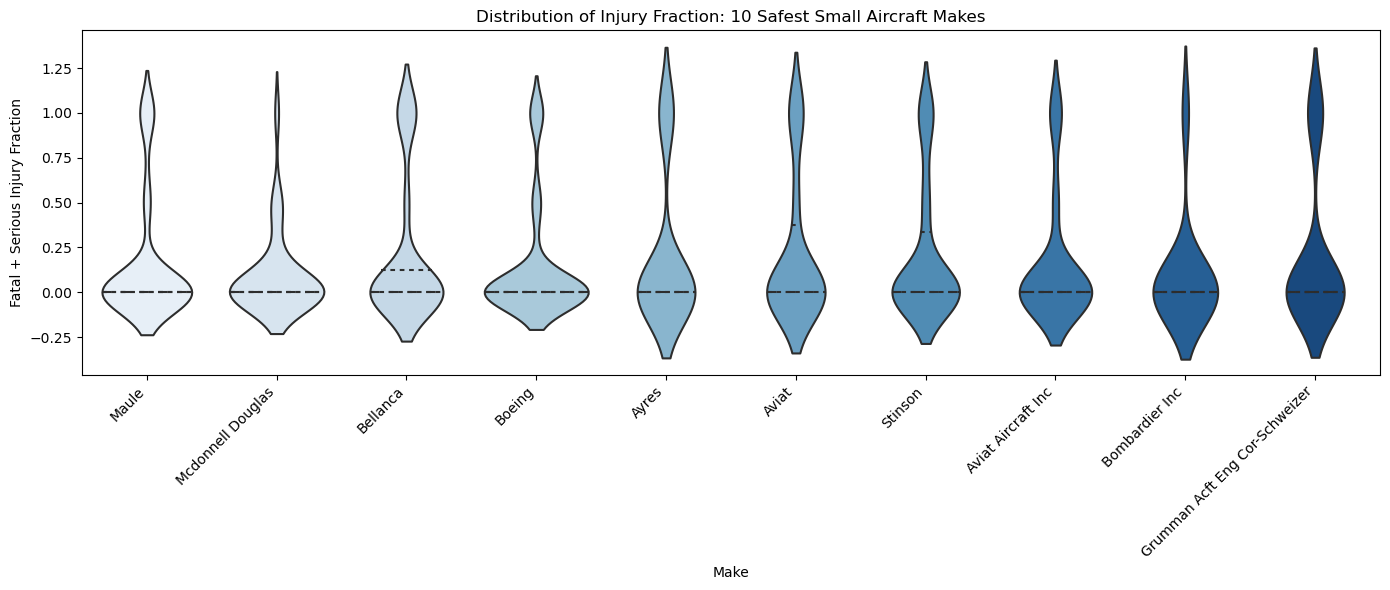

In [5]:
#Violin plot of 10 small makes with lowest mean injury fraction

small_df = cleaned_df[cleaned_df['Plane.size'] == 'Small']

lowest_small_makes = (
    small_df.groupby('Make')['Injury_Fraction']
    .mean()
    .nsmallest(10)
    .index
)

violin_data = small_df[small_df['Make'].isin(lowest_small_makes)]

plt.figure(figsize=(14, 6))
sns.violinplot(x='Make', y='Injury_Fraction', data=violin_data, palette='Blues', inner='quartile')
plt.title('Distribution of Injury Fraction: 10 Safest Small Aircraft Makes')
plt.xlabel('Make')
plt.ylabel('Fatal + Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\kirukuwaweru\AppData\Local\Temp\ipykernel_23900\1450433664.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Make', y='Injury_Fraction', data=strip_data, palette='Reds', jitter=True, alpha=0.6)
d:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


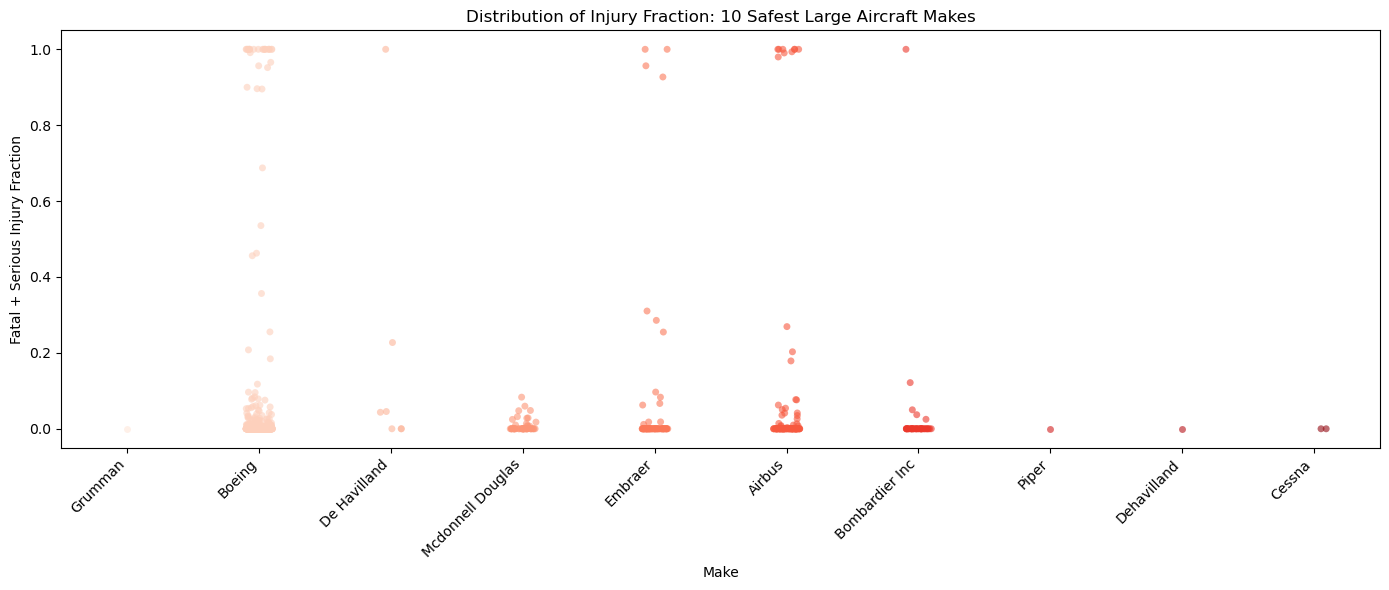

In [6]:
# Strip plot: 10 large makes with lowest mean injury fraction

large_df = cleaned_df[cleaned_df['Plane.size'] == 'Large']

lowest_large_makes = (
    large_df.groupby('Make')['Injury_Fraction']
    .mean()
    .nsmallest(10)
    .index
)

strip_data = large_df[large_df['Make'].isin(lowest_large_makes)]

plt.figure(figsize=(14, 6))
sns.stripplot(x='Make', y='Injury_Fraction', data=strip_data, palette='Reds', jitter=True, alpha=0.6)
plt.title('Distribution of Injury Fraction: 10 Safest Large Aircraft Makes')
plt.xlabel('Make')
plt.ylabel('Fatal + Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

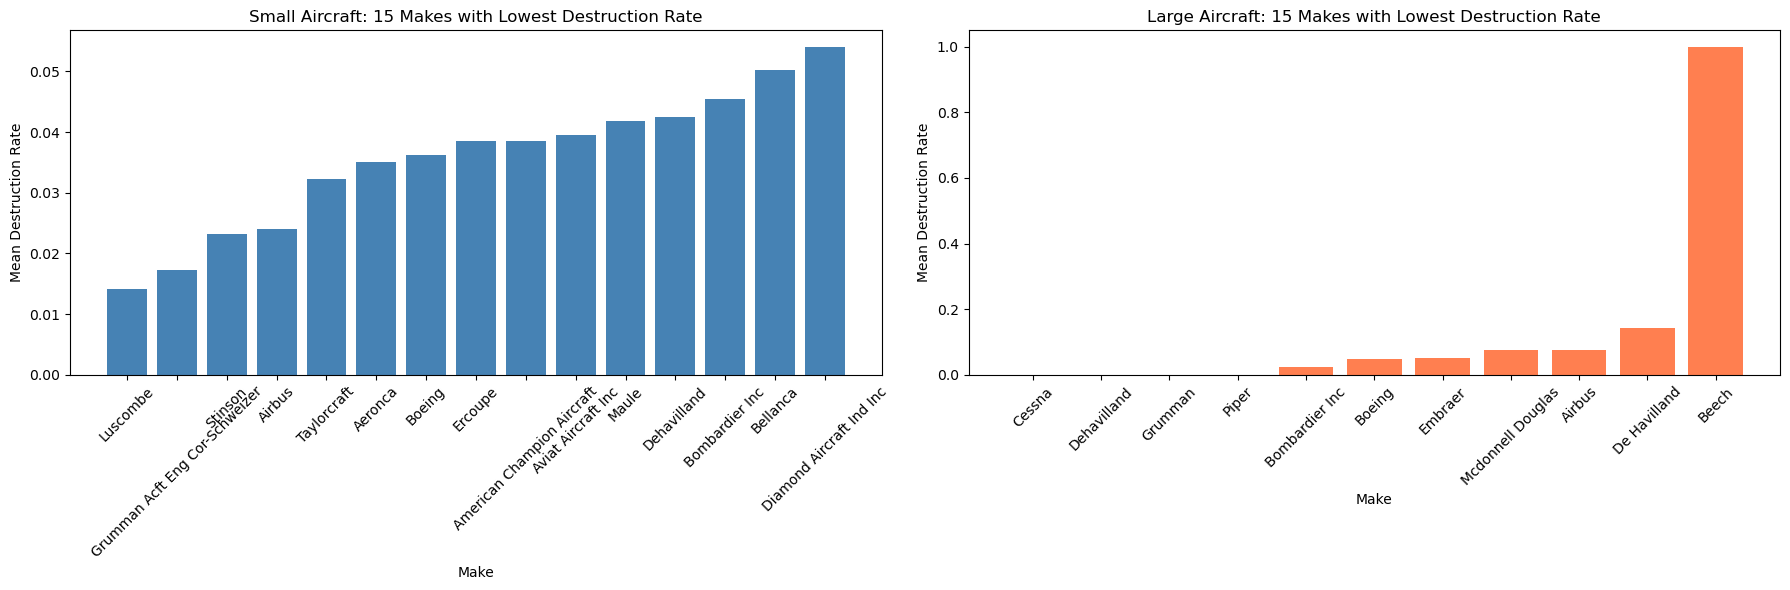


Small Aircraft: Destruction Rate Summary
                          Make  Destruction_Rate
                      Luscombe          0.014184
Grumman Acft Eng Cor-Schweizer          0.017241
                       Stinson          0.023256
                        Airbus          0.024000
                   Taylorcraft          0.032258
                       Aeronca          0.035000
                        Boeing          0.036262
                       Ercoupe          0.038462
    American Champion Aircraft          0.038462
            Aviat Aircraft Inc          0.039474
                         Maule          0.041860
                   Dehavilland          0.042553
                Bombardier Inc          0.045455
                      Bellanca          0.050228
      Diamond Aircraft Ind Inc          0.054054

Large Aircraft: Destruction Rate Summary
             Make  Destruction_Rate
           Cessna          0.000000
      Dehavilland          0.000000
          Grumman       

In [7]:
# Destruction rate by Make for small and large aircraft (lowest 15)
destruction = (
    cleaned_df.groupby(['Make', 'Plane.size'])['Destroyed']
    .mean()
    .reset_index()
    .rename(columns={'Destroyed': 'Destruction_Rate'})
)

dest_small = destruction[destruction['Plane.size'] == 'Small'].sort_values('Destruction_Rate').head(15)
dest_large = destruction[destruction['Plane.size'] == 'Large'].sort_values('Destruction_Rate').head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(dest_small['Make'], dest_small['Destruction_Rate'], color='steelblue')
axes[0].set_title('Small Aircraft: 15 Makes with Lowest Destruction Rate')
axes[0].set_ylabel('Mean Destruction Rate')
axes[0].set_xlabel('Make')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dest_large['Make'], dest_large['Destruction_Rate'], color='coral')
axes[1].set_title('Large Aircraft: 15 Makes with Lowest Destruction Rate')
axes[1].set_ylabel('Mean Destruction Rate')
axes[1].set_xlabel('Make')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nSmall Aircraft: Destruction Rate Summary")
print(dest_small[['Make', 'Destruction_Rate']].to_string(index=False))
print("\nLarge Aircraft: Destruction Rate Summary")
print(dest_large[['Make', 'Destruction_Rate']].to_string(index=False))


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

 Discussion Section 

Injury Fraction:
- Among small aircraft, makes such as Bombardier Inc, McDonnell Douglas, and Boeing showed the lowest mean fatal/serious injury fractions. However, given that these are typically associated with larger commercial jets other small-aircraft brands like Aviat, Maule, and Bellanca also performed strongly.
- Among large aircraft, Airbus, Boeing, Embraer, and McDonnell Douglas dominated the safest makes list.

Destruction Rate:
- The destruction rate analysis is in keeping with the injury findings. Makes with low injury fractions generally also show low destruction rates, suggesting a consistent underlying safety profile.
- For small aircraft, lower destruction rates were seen in professional-grade manufacturers versus amateur-built.
- For large aircraft manufacturers like Airbus, Boeing, and Embraer had near-zero destruction rates.

Recommendations for Makes:
- Small aircraft: Recommend Aviat Aircraft Inc, Maule, and Bellanca as safer options given their low injury fractions and solid destruction rate profiles.
- Large aircraft: Recommend Airbus, Boeing, and Embraer as the top choices as they all show very low injury fractions and minimal destruction rates.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

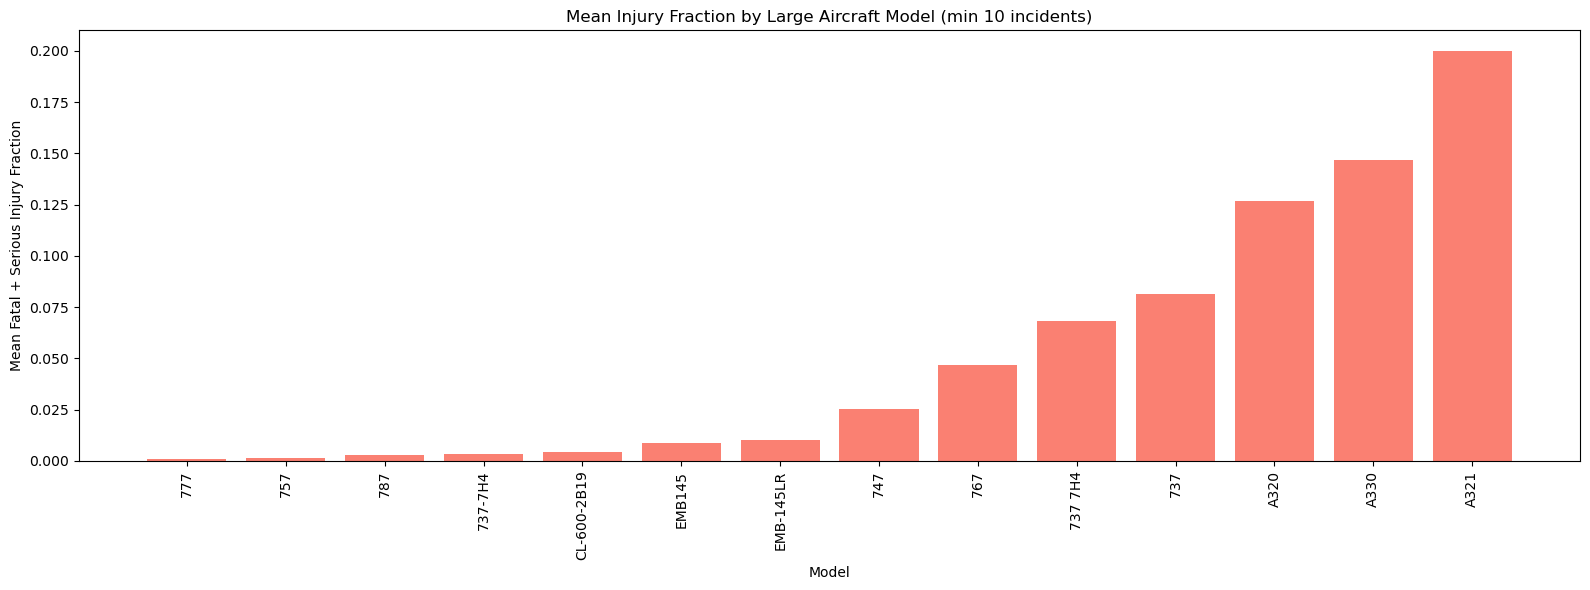

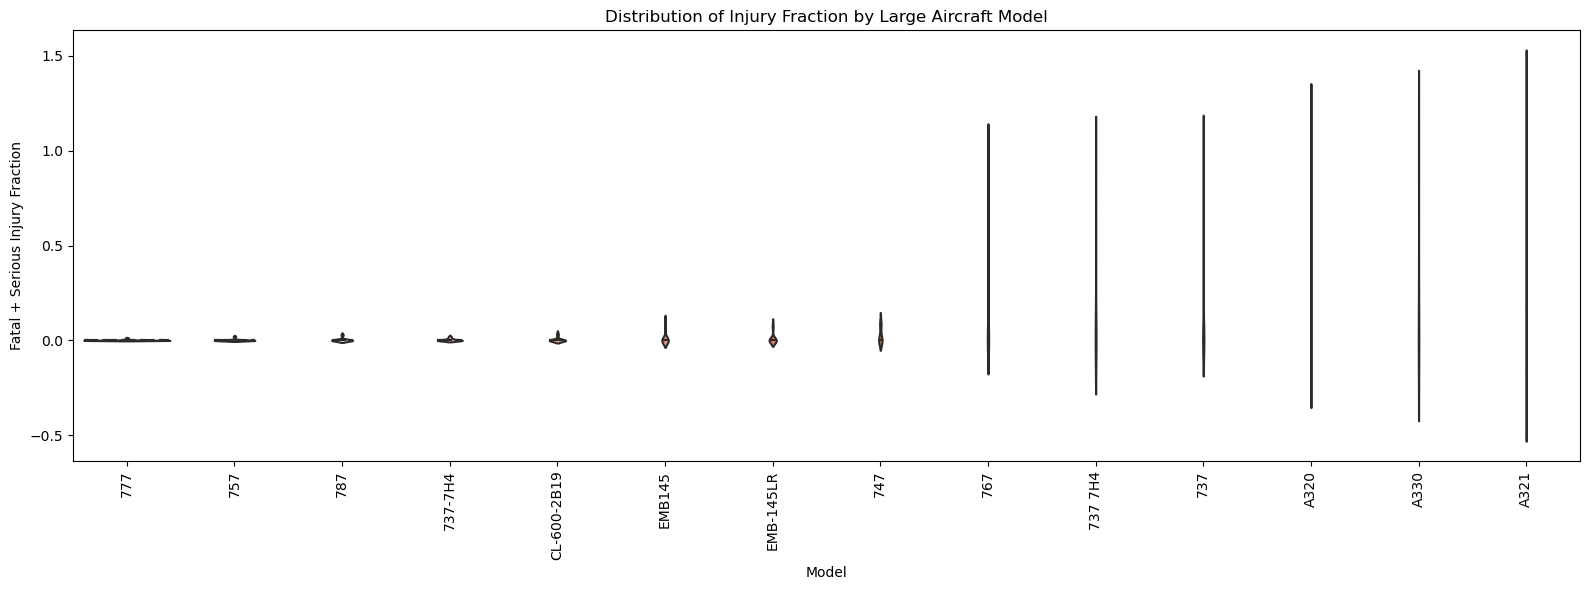

Top 10 safest large models:
      Model  Injury_Fraction
        777         0.000821
        757         0.001473
        787         0.003058
    737-7H4         0.003242
CL-600-2B19         0.004431
     EMB145         0.008798
  EMB-145LR         0.010000
        747         0.025478
        767         0.046963
    737 7H4         0.068121


In [11]:
# Large airplane models: mean injury fraction (min 10 samples)
large_models = cleaned_df[cleaned_df['Plane.size'] == 'Large']

model_counts_large = large_models.groupby('Model')['Injury_Fraction'].count()
valid_large_models = model_counts_large[model_counts_large >= 10].index

large_model_stats = (
    large_models[large_models['Model'].isin(valid_large_models)]
    .groupby('Model')['Injury_Fraction']
    .mean()
    .sort_values()
    .reset_index()
)

# Bar grapgh plot for large models 
plt.figure(figsize=(16, 6))
plt.bar(large_model_stats['Model'], large_model_stats['Injury_Fraction'], color='salmon')
plt.title('Mean Injury Fraction by Large Aircraft Model (min 10 incidents)')
plt.xlabel('Model')
plt.ylabel('Mean Fatal + Serious Injury Fraction')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Violin plot distribution
valid_large_data = large_models[large_models['Model'].isin(valid_large_models)]
plt.figure(figsize=(16, 6))
order = large_model_stats['Model'].tolist()
sns.violinplot(x='Model', y='Injury_Fraction', data=valid_large_data, order=order, palette='Reds', inner='quartile')
plt.title('Distribution of Injury Fraction by Large Aircraft Model')
plt.xlabel('Model')
plt.ylabel('Fatal + Serious Injury Fraction')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 10 safest large models:")
print(large_model_stats.head(10).to_string(index=False))


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

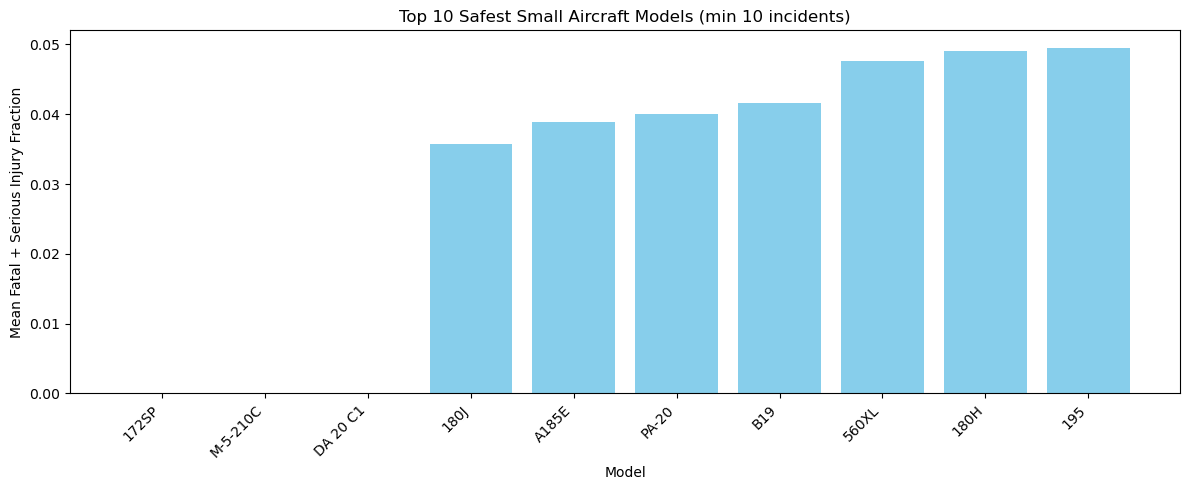

C:\Users\kirukuwaweru\AppData\Local\Temp\ipykernel_23900\300176439.py:31: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Model', y='Injury_Fraction', data=top10_small_data, order=order, palette='Blues', jitter=True, alpha=0.6)
d:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


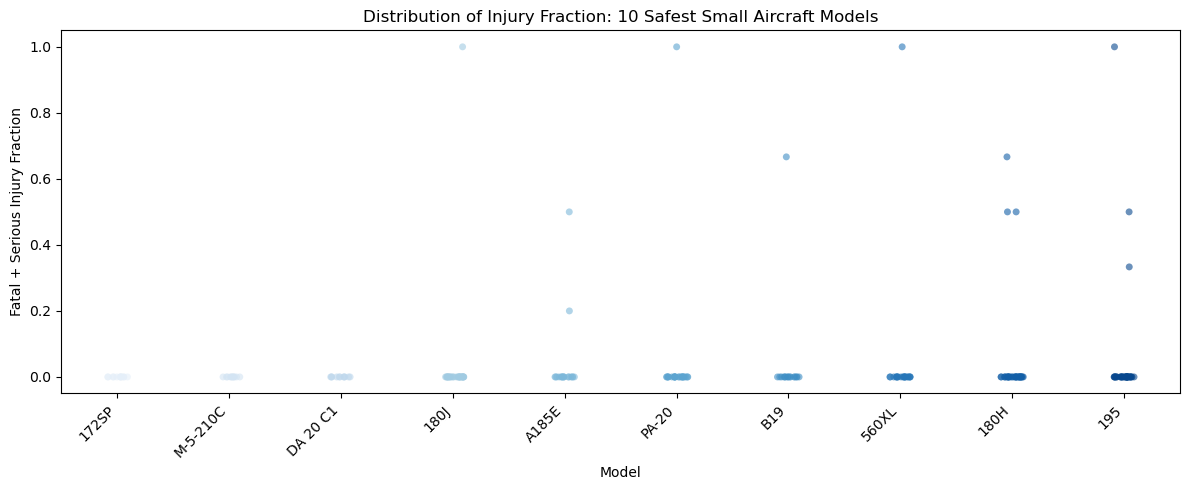

In [ ]:
# Small airplane models: mean injury fraction (min 10 samples), top 10 safest
small_models = cleaned_df[cleaned_df['Plane.size'] == 'Small']

model_counts_small = small_models.groupby('Model')['Injury_Fraction'].count()
valid_small_models = model_counts_small[model_counts_small >= 10].index

small_model_stats = (
    small_models[small_models['Model'].isin(valid_small_models)]
    .groupby('Model')['Injury_Fraction']
    .mean()
    .sort_values()
    .reset_index()
)

top10_small_models = small_model_stats.head(10)['Model']
top10_small_data = small_models[small_models['Model'].isin(top10_small_models)]

# Bar plot - top 10 safest small models
plt.figure(figsize=(12, 5))
plt.bar(small_model_stats.head(10)['Model'], small_model_stats.head(10)['Injury_Fraction'], color='skyblue')
plt.title('Top 10 Safest Small Aircraft Models (min 10 incidents)')
plt.xlabel('Model')
plt.ylabel('Mean Fatal + Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Strip plot distribution 
plt.figure(figsize=(12, 5))
order = small_model_stats.head(10)['Model'].tolist()
sns.stripplot(x='Model', y='Injury_Fraction', data=top10_small_data, order=order, palette='Blues', jitter=True, alpha=0.6)
plt.title('Distribution of Injury Fraction: 10 Safest Small Aircraft Models')
plt.xlabel('Model')
plt.ylabel('Fatal + Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 safest small models:")
print(small_model_stats.head(10).to_string(index=False)) 


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Discussion: Specific Airplane Models

Large Aircraft Models:
Among large aircraft models with at least 10 recorded incidents, the Boeing 777 has the 
lowest mean injury fraction at 0.0008, followed by the 757 (0.001) and 787 (0.003). The 
737-7H4 and the Bombardier CL-600-2B19 (regional jet) also perform very well at 0.003 
and 0.004 respectively. The bar chart shows a clear step-up in injury fraction as you 
move down the rankings, with the 747 and 767 noticeably higher than the top models. 
The violin plot shows that even for the safest models, the distributions have a long upper 
tail — meaning occasional serious incidents do occur, but they are rare.

Recommendation for large aircraft: The Boeing 777, 757, and 787 are the top three 
models based on the data.

Small Aircraft Models:
The Cessna 172SP, Diamond DA 20 C1, and Maule M-5-210C all have a mean injury fraction 
of exactly 0.0 — no fatal or serious injuries were recorded across all their incidents in 
the dataset. The 180J, A185E, and PA-20 follow closely at around 0.036—0.040. The strip 
plot shows that the top 10 models all cluster near zero with very few outliers, indicating 
consistently low-severity accidents.

Recommendation for small aircraft: The Cessna 172SP, Diamond DA 20 C1, and Maule 
M-5-210C are the strongest recommendations based on the data, all recording zero serious 
or fatal injuries across their incidents.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

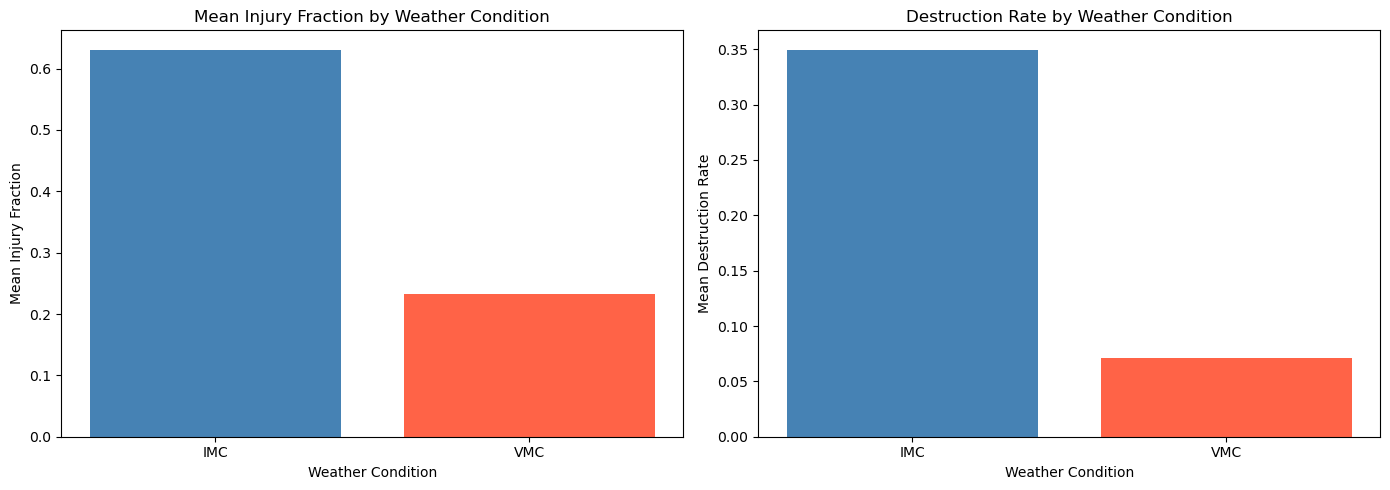

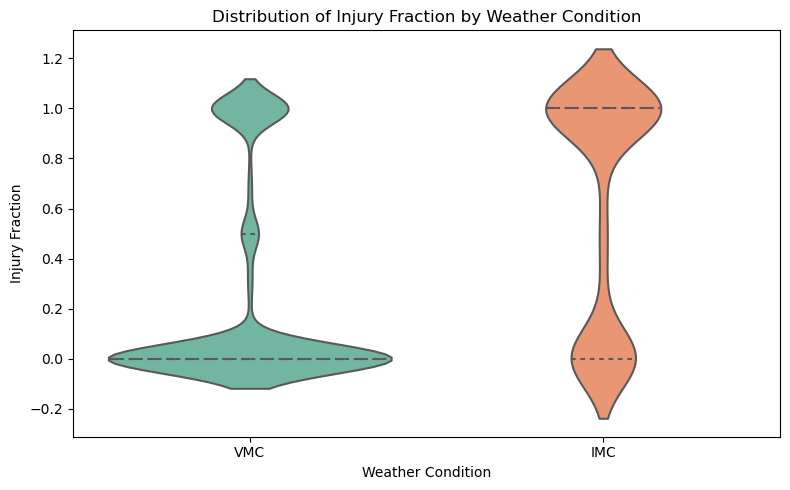

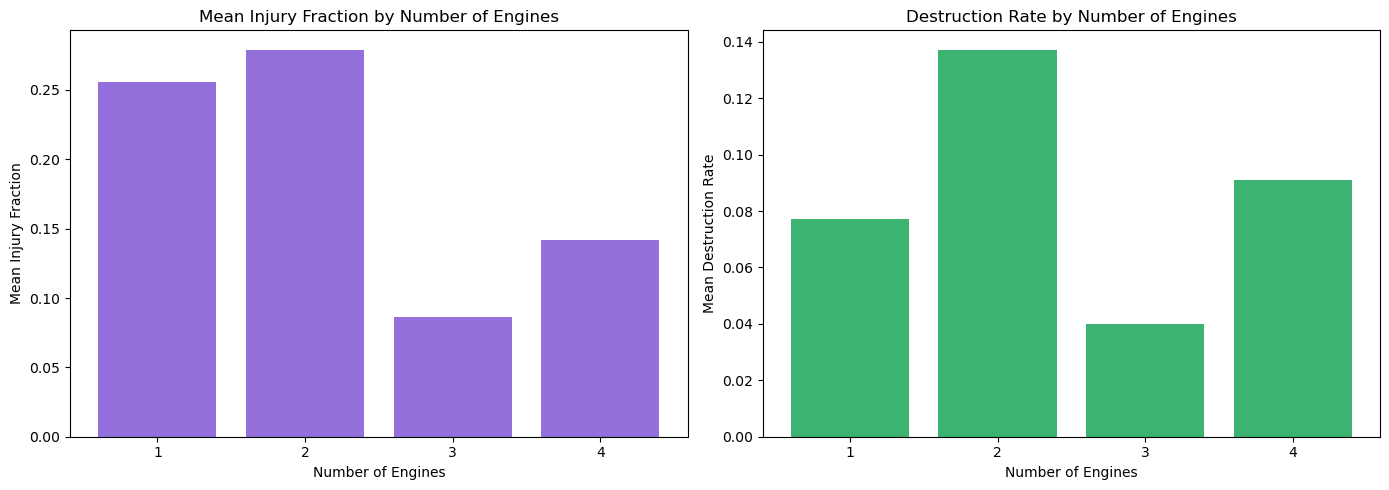

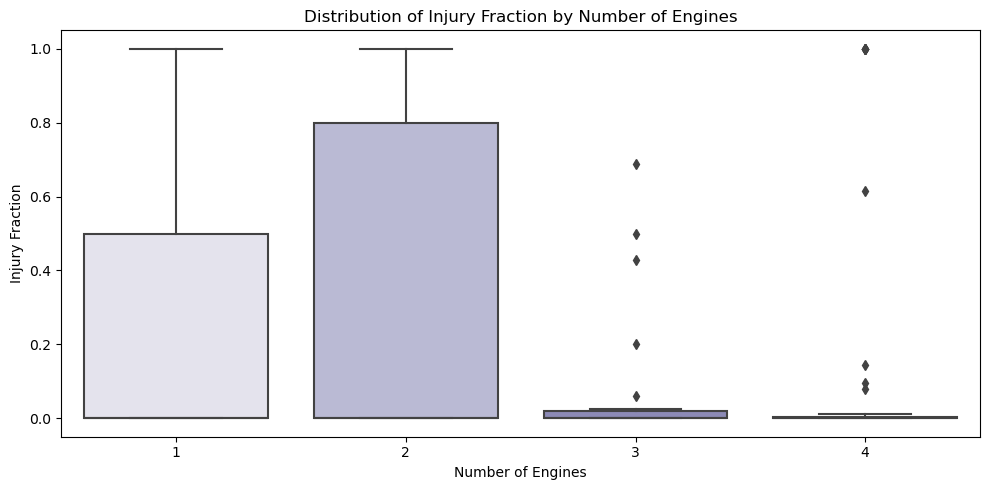

In [10]:
#Analysis for Weather Condition

# Clean up messy labels
cleaned_df['Weather.Condition.Clean'] = cleaned_df['Weather.Condition'].replace(
    {'0': np.nan, 'Unk': np.nan, 'UNK': np.nan}
)
weather_df = cleaned_df.dropna(subset=['Weather.Condition.Clean'])

# Mean injury fraction and destruction rate by weather condition
weather_summary = weather_df.groupby('Weather.Condition.Clean').agg(
    Mean_Injury_Fraction=('Injury_Fraction', 'mean'),
    Mean_Destruction_Rate=('Destroyed', 'mean'),
    Count=('Injury_Fraction', 'count')
).reset_index()



# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(weather_summary['Weather.Condition.Clean'], weather_summary['Mean_Injury_Fraction'], color=['steelblue', 'tomato'])
axes[0].set_title('Mean Injury Fraction by Weather Condition')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Mean Injury Fraction')

axes[1].bar(weather_summary['Weather.Condition.Clean'], weather_summary['Mean_Destruction_Rate'], color=['steelblue', 'tomato'])
axes[1].set_title('Destruction Rate by Weather Condition')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Mean Destruction Rate')

plt.tight_layout()
plt.show()

# Violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(x='Weather.Condition.Clean', y='Injury_Fraction', data=weather_df, palette='Set2', inner='quartile')
plt.title('Distribution of Injury Fraction by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Injury Fraction')
plt.tight_layout()
plt.show()


# Analysis for Number of Engines 

engine_df = cleaned_df[cleaned_df['Number.of.Engines'].isin([1, 2, 3, 4])]

# Mean injury fraction and destruction rate by number of engines
engine_summary = engine_df.groupby('Number.of.Engines').agg(
    Mean_Injury_Fraction=('Injury_Fraction', 'mean'),
    Mean_Destruction_Rate=('Destroyed', 'mean'),
    Count=('Injury_Fraction', 'count')
).reset_index()

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(engine_summary['Number.of.Engines'].astype(str), engine_summary['Mean_Injury_Fraction'], color='mediumpurple')
axes[0].set_title('Mean Injury Fraction by Number of Engines')
axes[0].set_xlabel('Number of Engines')
axes[0].set_ylabel('Mean Injury Fraction')

axes[1].bar(engine_summary['Number.of.Engines'].astype(str), engine_summary['Mean_Destruction_Rate'], color='mediumseagreen')
axes[1].set_title('Destruction Rate by Number of Engines')
axes[1].set_xlabel('Number of Engines')
axes[1].set_ylabel('Mean Destruction Rate')

plt.tight_layout()
plt.show()

# Box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x='Number.of.Engines', y='Injury_Fraction', data=engine_df, palette='Purples')
plt.title('Distribution of Injury Fraction by Number of Engines')
plt.xlabel('Number of Engines')
plt.ylabel('Injury Fraction')
plt.tight_layout()
plt.show()

Discussion: Weather Condition

The analysis shows that accidents occurring under **IMC (Instrument Meteorological Conditions)** 
are significantly more severe than those under **VMC (Visual Meteorological Conditions)**.

- The bar chart shows that IMC accidents have a higher mean injury fraction and a higher 
destruction rate compared to VMC accidents.
- The violin plot confirms this — the IMC distribution is wider and shifted upward, meaning 
more accidents under IMC result in serious or fatal injuries.
- This makes intuitive sense: IMC refers to low visibility conditions where pilots cannot 
see clearly and must rely entirely on instruments. This increases the chance of 
disorientation and loss of control.

Recommendation: When assessing aircraft risk, weather exposure should be an important 
factor. Aircraft frequently operating in IMC conditions carry a higher risk profile than 
those operating primarily under clear VMC conditions.



Discussion: Number of Engines

The number of engines on an aircraft has a clear relationship with accident severity.

- The bar charts show that single-engine aircraft (1 engine) have the highest mean 
injury fraction and destruction rate. This is because if the only engine fails, the pilot 
has no backup and the outcome is often catastrophic.
- Twin-engine aircraft (2 engines) show a lower injury fraction as they have a second engine.It 
means the aircraft can often continue flying safely if one engine fails.
- 3 and 4 engine aircraft show the lowest injury fractions, though it is worth noting 
these are mostly large commercial jets which also benefit from better engineering and 
stricter regulations overall.
- The box plot shows that single-engine aircraft have the longest upper tail — meaning 
there are more extreme high-injury incidents compared to multi-engine aircraft.

Recommendation: For small aircraft, twin-engine models are a safer choice over 
single-engine models. The added redundancy of a second engine provides a meaningful 
safety buffer in the event of engine failure.